# TDA Reference Persistence Images 구축 (Cold Start)

> **목적**: GCS P(t) 데이터 → 슬라이딩 윈도우 PI → K-Means 클러스터링으로 상태 발견  
> → `memory/cold_start/reference_images.json` + `baseline.json` 저장

**설계 원칙**  
- W-range로 상태를 미리 정의하지 않음 — TDA가 신호 위상 구조 차이로 상태를 직접 발견  
- 글로벌 정규화 (`signal / APPLIANCE_MAX_W`): 진폭 정보를 보존해 클러스터가 전력 수준으로 구분 가능  
- K 값과 상태명은 state_labeling.md EDA 결과를 사용 (TDA 발견 상태 ↔ W 분포 사후 검증)  
- baseline 통계(avg_energy_wh, avg_duration_min)도 K-Means 레이블에서 직접 계산 — W-range 재사용 없음

**입력**: GCS `training_dev10/` parquet (10가구, 30Hz P(t))  
**출력**: `{가전명: {상태명: [400-dim float list]}}` JSON  
**TDA 파라미터**: embed_dim=3, lag=10, VR thresh=0.5, PI 20×20 (mode_detector.py 동일)

In [13]:
!pip install -q gcsfs pyarrow scipy gudhi ripser scikit-learn

In [14]:
from google.colab import auth
auth.authenticate_user()
print('GCP 인증 완료')

GCP 인증 완료


In [15]:
import glob
import io
import json
import subprocess
import warnings
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import gcsfs
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import ripser as ripser_lib
from gudhi.representations import PersistenceImage
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
ttf = glob.glob('/usr/share/fonts/**/*Nanum*Gothic*.ttf', recursive=True)
if ttf:
    fm.fontManager.addfont(ttf[0])
    prop = fm.FontProperties(fname=ttf[0])
    plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print('임포트 완료')

임포트 완료


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BUCKET_PREFIX = 'ax-nilm-data-dhwang0803-us/nilm/training_dev10'
LABEL_PATH    = 'ax-nilm-data-dhwang0803-us/nilm/labels/training.parquet'

ALL_HOUSES = [
    'house_011', 'house_015', 'house_016', 'house_017',
    'house_033', 'house_039', 'house_049', 'house_054',
    'house_063', 'house_067',
]
AC_HOUSES = ['house_015', 'house_054', 'house_063']

EMBED_DIM    = 3
EMBED_LAG    = 10
MIN_POINTS   = 50
IMG_SIZE     = 20
MAX_EDGE_LEN = 0.5
PI_BANDWIDTH = 0.05
WINDOW_SIZE  = 512
WINDOW_STEP  = 512
MIN_SEG_LEN  = 100

MAX_WINDOWS_PER_APPLIANCE = 2000

SKIP_HOUSES = {'house_017'}

OUTPUT_DIR      = Path('/content/drive/MyDrive/ax_nilm_cold_start')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH     = OUTPUT_DIR / 'reference_images.json'
BASELINE_PATH   = OUTPUT_DIR / 'baseline.json'

APPLIANCE_MAX_W = {
    '에어컨':            50.0,
    '김치냉장고':        200.0,
    '제습기':            500.0,
    '세탁기':            700.0,
    '일반 냉장고':       400.0,
    '식기세척기/건조기': 2000.0,
    '전기밥솥':          1500.0,
    '전기장판/담요':     200.0,
}

STATE_COUNT = {
    '에어컨':            2,
    '김치냉장고':        3,
    '제습기':            2,
    '세탁기':            3,
    '일반 냉장고':       2,
    '식기세척기/건조기': 3,
    '전기밥솥':          2,
    '전기장판/담요':     2,
}

STATE_NAMES = {
    '에어컨':            ['cool', 'warmup'],
    '김치냉장고':        ['fan', 'cool_low', 'cool_high'],
    '제습기':            ['fan_only', 'dehumid'],
    '세탁기':            ['wash_A', 'wash_B', 'wash'],      # 빌드 후 avg_w 확인 → rename 셀에서 최종 명명
    '일반 냉장고':       ['cool_A', 'cool_B'],              # 빌드 후 avg_w 확인 → defrost 여부 판단 후 명명
    '식기세척기/건조기': ['rinse', 'wash', 'heat_dry'],
    '전기밥솥':          ['keep_warm', 'cook'],
    '전기장판/담요':     ['low', 'high'],
}

WINDOW_SIZE_OVERRIDE = {
    '식기세척기/건조기': 2048,
}

TDA_APPLIANCES_CONFIG = {
    '에어컨':            {'label_key': '에어컨',      'houses': AC_HOUSES},
    '김치냉장고':        {'label_key': '김치 냉장고',  'houses': ALL_HOUSES},
    '제습기':            {'label_key': '제습기',       'houses': ALL_HOUSES},
    '세탁기':            {'label_key': '세탁기',       'houses': ALL_HOUSES},
    '일반 냉장고':       {'label_key': '일반 냉장고',  'houses': ALL_HOUSES},
    '식기세척기/건조기': {'label_key': '식기세척기',   'houses': ALL_HOUSES},
    '전기밥솥':          {'label_key': '전기밥솥',     'houses': ALL_HOUSES},
    '전기장판/담요':     {'label_key': '전기장판',     'houses': ALL_HOUSES},
}

print(f'TDA 가전 {len(TDA_APPLIANCES_CONFIG)}종 (의류건조기·온수매트 제외 — W-range)')
print(f'출력 경로: {OUTPUT_PATH}')
print()
print('STATE_COUNT:')
for k, v in STATE_COUNT.items():
    override = f'  WINDOW={WINDOW_SIZE_OVERRIDE[k]}' if k in WINDOW_SIZE_OVERRIDE else ''
    print(f'  {k}: K={v}{override}')

In [17]:
gcs = gcsfs.GCSFileSystem()
pa_fs = pa.fs.PyFileSystem(pa.fs.FSSpecHandler(gcs))

labels_df = pq.read_table(LABEL_PATH, filesystem=pa_fs).to_pandas()
print('라벨 컬럼:', labels_df.columns.tolist())
print('총 레코드:', len(labels_df))
labels_df.head(3)

라벨 컬럼: ['household_id', 'channel', 'date', 'appliance_type', 'appliance_name', 'brand', 'start_ts', 'end_ts']
총 레코드: 465001


,household_id,channel,date,appliance_type,appliance_name,brand,start_ts,end_ts
0,house_001,ch01,20230928,main power,메인 분전반,메인 분전반,2023-09-28,2023-09-28 23:59:59.967
1,house_001,ch01,20230922,main power,메인 분전반,메인 분전반,2023-09-22,2023-09-22 23:59:59.967
2,house_001,ch01,20230923,main power,메인 분전반,메인 분전반,2023-09-23,2023-09-23 23:59:59.967


In [18]:
appliance_channels = {}

for app_name, cfg in TDA_APPLIANCES_CONFIG.items():
    rows = labels_df[
        labels_df['appliance_name'].str.contains(cfg['label_key'], na=False) &
        labels_df['household_id'].isin(cfg['houses'])
    ][['household_id', 'channel']].drop_duplicates()

    channels = list(rows.itertuples(index=False, name=None))
    appliance_channels[app_name] = channels
    print(f'{app_name}: {len(channels)}개 채널')

에어컨: 3개 채널
김치냉장고: 6개 채널
제습기: 5개 채널
세탁기: 8개 채널
의류건조기: 6개 채널
일반 냉장고: 8개 채널
식기세척기/건조기: 3개 채널
온수매트: 4개 채널
전기밥솥: 8개 채널
전기장판/담요: 7개 채널


In [19]:
def get_on_periods(house_id, channel):
    rows = labels_df[
        (labels_df['household_id'] == house_id) &
        (labels_df['channel'] == channel)
    ]
    periods = []
    for _, row in rows.iterrows():
        s = pd.to_datetime(row.get('start_ts'))
        e = pd.to_datetime(row.get('end_ts'))
        if pd.notna(s) and pd.notna(e):
            s = s.tz_convert('UTC').tz_localize(None) if s.tzinfo else s
            e = e.tz_convert('UTC').tz_localize(None) if e.tzinfo else e
            periods.append((s, e))
    return periods


def load_raw_channel(house_id, channel):
    periods = get_on_periods(house_id, channel)
    if not periods:
        return pd.DataFrame(columns=['date_time', 'active_power'])

    on_dates = set()
    for s, e in periods:
        d = s.date()
        while d <= e.date():
            on_dates.add(d.strftime('%Y%m%d'))
            d += pd.Timedelta(days=1)

    path = f'{BUCKET_PREFIX}/household_id={house_id}/channel={channel}'
    files = []
    for date in sorted(on_dates):
        try:
            files.extend(gcs.ls(f'{path}/date={date}'))
        except Exception:
            pass

    if not files:
        return pd.DataFrame(columns=['date_time', 'active_power'])

    def _read(f):
        with gcs.open(f, 'rb') as fp:
            buf = fp.read()
        return pq.read_table(io.BytesIO(buf), columns=['date_time', 'active_power']).to_pandas()

    with ThreadPoolExecutor(max_workers=8) as pool:
        dfs = list(pool.map(_read, files))

    df = pd.concat(dfs, ignore_index=True)
    df['date_time'] = pd.to_datetime(df['date_time']).dt.tz_localize(None)
    return df.sort_values('date_time').reset_index(drop=True)


def extract_on_segments(house_id, channel):
    raw = load_raw_channel(house_id, channel)
    periods = get_on_periods(house_id, channel)
    if not periods:
        return []
    raw = raw.set_index('date_time').sort_index()
    result = []
    for s, e in periods:
        seg = raw.loc[s:e, 'active_power'].values.astype(np.float32)
        if len(seg) >= MIN_SEG_LEN:
            result.append(seg)
    return result


print('데이터 로드 함수 정의 완료')

데이터 로드 함수 정의 완료


In [ ]:
_PI = PersistenceImage(
    bandwidth=PI_BANDWIDTH,
    resolution=[IMG_SIZE, IMG_SIZE],
    im_range=[0, 1, 0, 1],
)

MAX_EMBED_PTS = 512  # ripser 입력 포인트 상한 — 초과 시 균등 다운샘플링


def time_delay_embed(signal, dim=EMBED_DIM, lag=EMBED_LAG):
    n = len(signal) - (dim - 1) * lag
    if n <= 0:
        return np.empty((0, dim))
    return np.stack([signal[i: i + n] for i in range(0, dim * lag, lag)], axis=1)


def compute_fingerprint(window, max_w):
    """윈도우 P(t) → PI 벡터. 글로벌 정규화로 진폭 정보 보존."""
    if len(window) < MIN_POINTS:
        return None
    norm = np.clip(window / max_w, 0.0, 1.0).astype(np.float32)
    if norm.max() < 1e-6:
        return None
    # 큰 윈도우(예: 식기세척기 2048)는 균등 다운샘플링 → ripser 포인트 수 유지
    if len(norm) > MAX_EMBED_PTS:
        step = len(norm) // MAX_EMBED_PTS
        norm = norm[::step][:MAX_EMBED_PTS]
    cloud = time_delay_embed(norm)
    if len(cloud) < MIN_POINTS:
        return None
    result = ripser_lib.ripser(cloud, maxdim=1, thresh=MAX_EDGE_LEN)
    dgm = result['dgms'][1]
    if len(dgm) == 0:
        return np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
    dgm_finite = dgm[dgm[:, 1] != np.inf]
    if len(dgm_finite) == 0:
        return np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
    img = _PI.fit_transform([dgm_finite])
    return img[0].flatten().astype(np.float32)


print('TDA 함수 정의 완료 (글로벌 정규화, 최대 임베딩 포인트:', MAX_EMBED_PTS, ')')

## 사전 정리: 재빌드할 가전 JSON에서 제거 (메인 루프 실행 전 반드시 먼저 실행)

K값·WINDOW가 변경된 가전과 TDA→W-range 전환 가전을 기존 JSON에서 제거.  
이 셀을 실행하지 않으면 메인 루프가 기존 결과를 그대로 스킵함.

In [ ]:
REBUILD_APPLIANCES = [
    '에어컨',            # K 3→2
    '제습기',            # K 3→2
    '세탁기',            # K 2→3
    '일반 냉장고',       # K 3→2
    '식기세척기/건조기', # WINDOW 512→2048
    '의류건조기',        # TDA 제외 → W-range 전환, 기존 TDA 레퍼런스 제거
    '온수매트',          # TDA 폴백 → W-range 전환, 기존 TDA 레퍼런스 제거
]

for path in [OUTPUT_PATH, BASELINE_PATH]:
    if not path.exists():
        print(f'{path.name} 없음, 스킵')
        continue
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    removed = []
    for app in REBUILD_APPLIANCES:
        if app in data:
            del data[app]
            removed.append(app)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f'{path.name}: {removed} 제거 완료')
    print(f'  남은 항목: {list(data.keys())}')

## 메인 루프: PI 수집 → K-Means → 레퍼런스 + Baseline

각 가전에 대해:
1. 전체 ON 구간에서 슬라이딩 윈도우 512샘플 추출 (session_id 추적 포함)
2. 윈도우별 PI 계산 (글로벌 정규화)
3. K-Means(K=STATE_COUNT) 클러스터링
4. 클러스터별 평균W 오름차순 → STATE_NAMES 순서대로 이름 부여 → 클러스터 중심 = reference PI
5. 클러스터 레이블 + session 정보로 avg_energy_wh / avg_duration_min 계산 → baseline

In [ ]:
if OUTPUT_PATH.exists():
    with open(OUTPUT_PATH, encoding='utf-8') as f:
        reference_images = json.load(f)
    print(f'기존 reference 로드: {list(reference_images.keys())}')
else:
    reference_images = {}

if BASELINE_PATH.exists():
    with open(BASELINE_PATH, encoding='utf-8') as f:
        baseline = json.load(f)
    print(f'기존 baseline 로드: {list(baseline.keys())}')
else:
    baseline = {}

SAMPLE_S = 1.0 / 30.0

for app_name, cfg in TDA_APPLIANCES_CONFIG.items():
    if app_name in reference_images and app_name in baseline:
        print(f'[{app_name}] 이미 완료, 스킵')
        continue

    max_w    = APPLIANCE_MAX_W[app_name]
    K        = STATE_COUNT[app_name]
    names    = STATE_NAMES[app_name]
    channels = appliance_channels.get(app_name, [])
    win_size = WINDOW_SIZE_OVERRIDE.get(app_name, WINDOW_SIZE)
    win_step = win_size  # non-overlapping

    if not channels:
        print(f'[{app_name}] 채널 없음, 스킵')
        continue

    print(f'\n[{app_name}] K={K}, max_w={max_w}W, win={win_size}샘플({win_size/30:.1f}s)')

    all_pis          = []
    all_ws           = []
    all_session_keys = []
    all_win_idxs     = []

    for house_id, channel in channels:
        if house_id in SKIP_HOUSES:
            continue
        if len(all_pis) >= MAX_WINDOWS_PER_APPLIANCE:
            print(f'  캡 도달({MAX_WINDOWS_PER_APPLIANCE}), GCS 로딩 중단')
            break

        print(f'  [{house_id}/{channel}] 로드 중...')
        on_segments = extract_on_segments(house_id, channel)
        print(f'  [{house_id}/{channel}] ON 구간 {len(on_segments)}개')

        for seg_idx, seg in enumerate(on_segments):
            if len(all_pis) >= MAX_WINDOWS_PER_APPLIANCE:
                break
            sess_key = (house_id, channel, seg_idx)
            win_idx = 0
            for start in range(0, len(seg) - win_size + 1, win_step):
                if len(all_pis) >= MAX_WINDOWS_PER_APPLIANCE:
                    break
                window = seg[start: start + win_size]
                pi = compute_fingerprint(window, max_w)
                if pi is not None:
                    all_pis.append(pi)
                    all_ws.append(float(window.mean()))
                    all_session_keys.append(sess_key)
                    all_win_idxs.append(win_idx)
                win_idx += 1

    n_pis = len(all_pis)
    print(f'  수집된 PI: {n_pis}개')

    if n_pis < K * 30:
        print(f'  ⚠️ PI 부족 ({n_pis} < {K*30}) — 영벡터/영값으로 대체')
        reference_images[app_name] = {name: [0.0] * (IMG_SIZE * IMG_SIZE) for name in names}
        baseline[app_name] = {name: {'avg_energy_wh': 0.0, 'avg_duration_min': 0.0, 'sample_count': 0} for name in names}
    else:
        X = np.stack(all_pis)
        W = np.array(all_ws)

        km = KMeans(n_clusters=K, random_state=42, n_init=10)
        labels = km.fit_predict(X)

        cluster_mean_w = np.array([W[labels == k].mean() for k in range(K)])
        sorted_idx = np.argsort(cluster_mean_w)

        app_ref = {}
        cluster_to_state = {}
        for rank, cluster_idx in enumerate(sorted_idx):
            state_name = names[rank]
            count = int((labels == cluster_idx).sum())
            avg_w_c = float(cluster_mean_w[cluster_idx])
            app_ref[state_name] = km.cluster_centers_[cluster_idx].tolist()
            cluster_to_state[cluster_idx] = state_name
            print(f'  클러스터{cluster_idx} → {state_name}: {count}개 윈도우, 평균W={avg_w_c:.1f}')

        reference_images[app_name] = app_ref

        state_energies  = defaultdict(list)
        state_durations = defaultdict(list)

        sess_group = defaultdict(list)
        for sess_key, w_idx, cluster_label, mean_w in zip(
            all_session_keys, all_win_idxs, labels, all_ws
        ):
            sess_group[sess_key].append((w_idx, int(cluster_label), mean_w))

        for sess_key, entries in sess_group.items():
            entries.sort(key=lambda x: x[0])
            win_idxs_arr = [e[0] for e in entries]
            cluster_arr  = [e[1] for e in entries]

            prev_cluster = None
            run_start_j  = 0
            for j in range(len(entries) + 1):
                cur_cluster = cluster_arr[j] if j < len(entries) else None
                is_continuous = (
                    j < len(entries) and
                    cur_cluster == prev_cluster and
                    (j == 0 or win_idxs_arr[j] == win_idxs_arr[j - 1] + 1)
                )
                if not is_continuous:
                    if prev_cluster is not None:
                        run = entries[run_start_j:j]
                        n_run = len(run)
                        total_samples = (n_run - 1) * win_step + win_size
                        dur_s      = total_samples * SAMPLE_S
                        mean_w_run = sum(e[2] for e in run) / n_run
                        state_name = cluster_to_state[prev_cluster]
                        state_durations[state_name].append(dur_s / 60.0)
                        state_energies[state_name].append(mean_w_run * dur_s / 3600.0)
                    run_start_j  = j
                    prev_cluster = cur_cluster

        app_baseline = {}
        for state_name in names:
            energies  = state_energies[state_name]
            durations = state_durations[state_name]
            n = len(energies)
            avg_energy   = round(float(np.mean(energies)),  3) if n else 0.0
            avg_duration = round(float(np.mean(durations)), 1) if n else 0.0
            entry = {
                'avg_energy_wh':    avg_energy,
                'avg_duration_min': avg_duration,
                'sample_count':     n,
            }
            ref_vec = app_ref.get(state_name, [])
            if ref_vec and any(v != 0.0 for v in ref_vec):
                entry['tda_reference'] = ref_vec
            app_baseline[state_name] = entry
            warn = ' ⚠️ 샘플 없음' if n == 0 else ''
            print(f'  baseline {state_name}: {avg_energy:.1f}Wh  {avg_duration:.1f}min  ({n}개){warn}')

        baseline[app_name] = app_baseline

    with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
        json.dump(reference_images, f, ensure_ascii=False, indent=2)
    with open(BASELINE_PATH, 'w', encoding='utf-8') as f:
        json.dump(baseline, f, ensure_ascii=False, indent=2)
    print(f'  → 저장 완료')

print('\n=== 전체 완료 ===')
for app, refs in reference_images.items():
    ok = [s for s, v in refs.items() if any(x != 0.0 for x in v)]
    ng = [s for s, v in refs.items() if all(x == 0.0 for x in v)]
    print(f'{app}: 유효 {len(ok)}{ok}  영벡터 {len(ng)}{ng}')

## 상태명 재명명 (빌드 후 avg_w 확인 후 실행)

메인 루프 출력에서 각 클러스터의 `평균W`를 확인하고, 아래 `RENAME_MAP`을 채운 뒤 실행.  
클러스터링 재실행 없이 JSON 키(상태명)만 변경됨.

In [ ]:
# JSON 내 영문 state 키 → 한국어로 일괄 변환
# 대상: reference_images.json, baseline.json 내 TDA 8종 전체
RENAME_MAP = {
    '에어컨':           {'cool': '냉방', 'warmup': '예열'},
    '김치냉장고':       {'fan': '팬', 'cool_low': '약냉', 'cool_high': '강냉'},
    '제습기':           {'fan_only': '송풍', 'dehumid': '제습'},
    '세탁기':           {'wash_A': '헹굼', 'wash_B': '세탁', 'wash': '탈수'},
    '일반 냉장고':      {'cool_A': '냉각', 'cool_B': '장시간 냉각'},
    '식기세척기/건조기':{'rinse': '예비헹굼', 'wash': '세척', 'heat_dry': '열풍건조'},
    '전기밥솥':         {'keep_warm': '보온', 'cook': '취사'},
    '전기장판/담요':    {'low': '약', 'high': '강'},
}

def rename_states(data, rename_map):
    for app_name, name_map in rename_map.items():
        if app_name not in data:
            print(f'⚠️ {app_name} 없음, 스킵')
            continue
        new_entry = {name_map.get(k, k): v for k, v in data[app_name].items()}
        data[app_name] = new_entry
        print(f'{app_name}: {list(data[app_name].keys())}')
    return data

for path in [OUTPUT_PATH, BASELINE_PATH]:
    if not path.exists():
        print(f'{path.name} 없음')
        continue
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    data = rename_states(data, RENAME_MAP)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f'{path.name} 저장 완료')

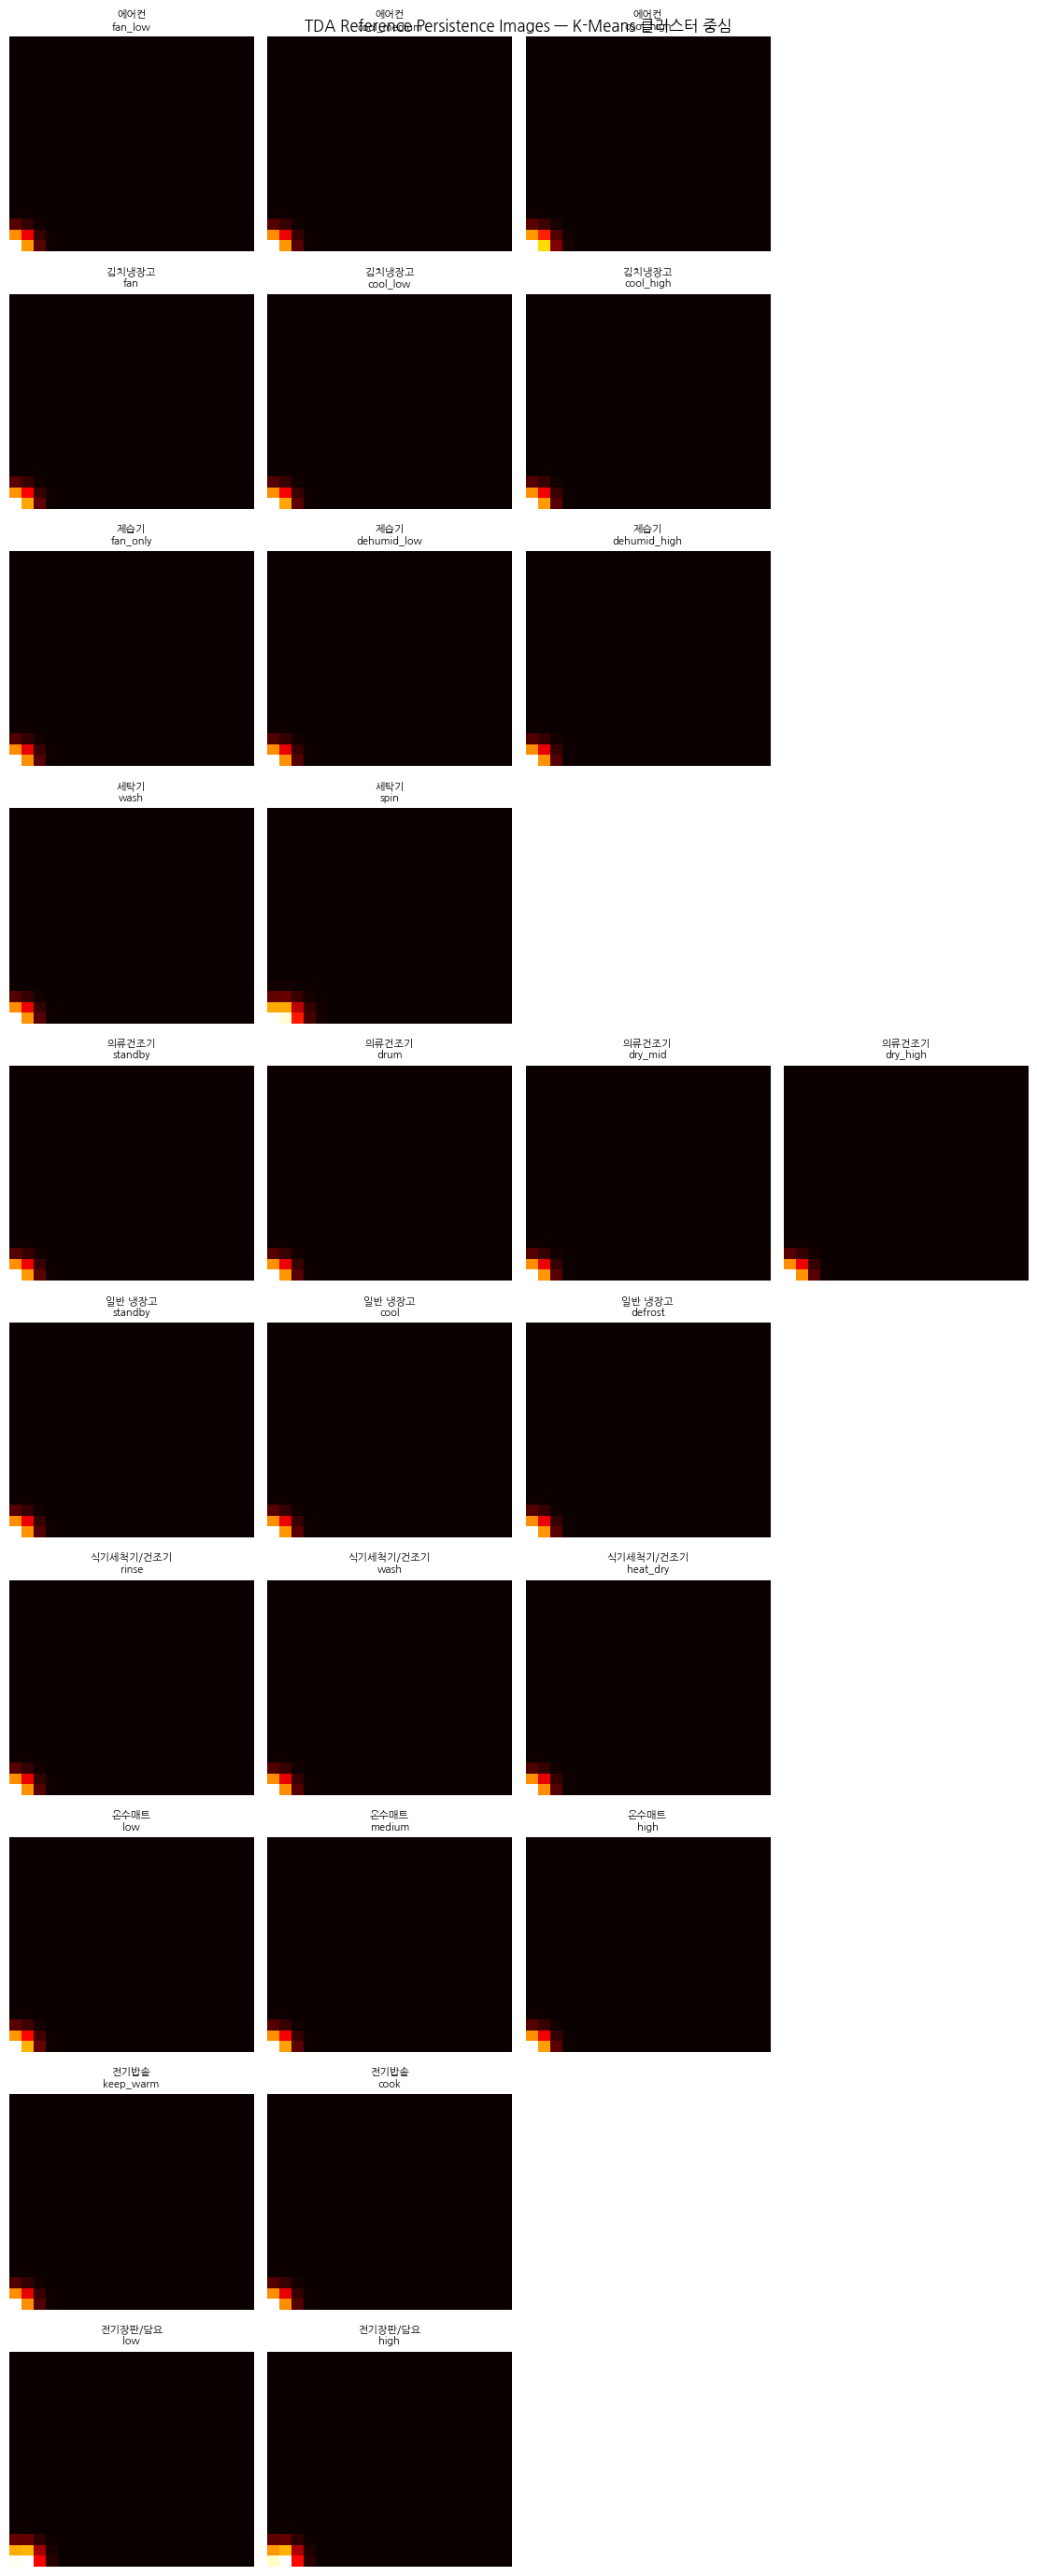

저장: /content/drive/MyDrive/ax_nilm_cold_start/reference_images_preview.png
빨간 제목 = 영벡터


In [23]:
max_states = max(len(v) for v in reference_images.values()) if reference_images else 1
n_apps = len(reference_images)

fig, axes = plt.subplots(
    n_apps, max_states,
    figsize=(max_states * 2.8, n_apps * 2.8),
    squeeze=False,
)

for row_i, (app_name, state_refs) in enumerate(reference_images.items()):
    for col_i, (state_name, ref_vec) in enumerate(state_refs.items()):
        ax = axes[row_i][col_i]
        vec = np.array(ref_vec).flatten()
        if vec.size != IMG_SIZE * IMG_SIZE:
            img, nonzero = np.zeros((IMG_SIZE, IMG_SIZE)), 0
        else:
            img = vec.reshape(IMG_SIZE, IMG_SIZE)
            nonzero = np.count_nonzero(img)
        ax.imshow(img, origin='lower', cmap='hot', aspect='auto')
        color = 'black' if nonzero > 0 else 'red'
        ax.set_title(f'{app_name}\n{state_name}', fontsize=8, color=color)
        ax.axis('off')
    for col_i in range(len(state_refs), max_states):
        axes[row_i][col_i].axis('off')

plt.suptitle('TDA Reference Persistence Images — K-Means 클러스터 중심', fontsize=12)
plt.tight_layout()
preview_path = OUTPUT_DIR / 'reference_images_preview.png'
plt.savefig(str(preview_path), dpi=100, bbox_inches='tight')
plt.show()
print(f'저장: {preview_path}')
print('빨간 제목 = 영벡터')

In [24]:
print(f'출력 폴더: {OUTPUT_DIR}')
print('산출물:')
print(f'  {OUTPUT_PATH}    ← memory/cold_start/reference_images.json 으로 복사')
print(f'  {BASELINE_PATH}  ← memory/cold_start/baseline.json 으로 복사')
print(f'  {OUTPUT_DIR / "reference_images_preview.png"}  ← 시각화 확인용')

출력 폴더: /content/drive/MyDrive/ax_nilm_cold_start
산출물:
  /content/drive/MyDrive/ax_nilm_cold_start/reference_images.json    ← memory/cold_start/reference_images.json 으로 복사
  /content/drive/MyDrive/ax_nilm_cold_start/baseline.json  ← memory/cold_start/baseline.json 으로 복사
  /content/drive/MyDrive/ax_nilm_cold_start/reference_images_preview.png  ← 시각화 확인용
